# **Анализ поведения пользователей в обновлённом игровом приложении**
## Цели исследования:
1. Определить, насколько обучение сокращает время прохождения этапов игры.
2. Доказать, что успешное обучение само по себе влияет на оплату и не имеет значения то, каким этапом оно шло.
3. Проверить, насколько прозрачен процесс взаимодействия с игрой.

In [1]:
# Выгружаем данные. Приводим дату в единый формат.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
events_df = pd.read_csv(r'C:\Users\днс\Downloads\events.csv', sep=',')
purchase_df = pd.read_csv(r'C:\Users\днс\Downloads\purchase.csv', sep=',')
events_df['start_time'] = pd.to_datetime(events_df['start_time'], errors='coerce')
purchase_df['event_datetime'] = pd.to_datetime(purchase_df['event_datetime'], errors='coerce')

# Фильтруем пользователей. Оставляем только тех, кто зарегистрировался в 2018 году.

mask1 = events_df['start_time'] >= '2018-01-01'
mask2 = events_df['start_time'] < '2019-01-01'
mask3 = events_df['event_type'] == 'registration'
users_2018 = events_df[mask1 & mask2 & mask3]['user_id'].to_list()
events_df  = events_df[events_df['user_id'].isin(users_2018)]
purchase_df  = purchase_df[purchase_df['user_id'].isin(users_2018)]

# Добавляем событие оплаты, переименовываем столбцы, объединяем таблицы.

purchase_df  = purchase_df[purchase_df['user_id'].isin(users_2018)]
purchase_df['event_type'] = 'purchase'
events_df = events_df.rename(columns={"id": "event_id"})
purchase_df = purchase_df.rename(columns={"id": "purchase_id", "event_datetime": "start_time"})
total_events_df = pd.concat([events_df,purchase_df],sort=False)

# Добавляем событие оплаты, переименовываем столбцы, чтобы в итоге соеденить таблицы.

purchase_df  = purchase_df[purchase_df['user_id'].isin(users_2018)]
purchase_df['event_type'] = 'purchase'
events_df = events_df.rename(columns={"id": "event_id"})
purchase_df = purchase_df.rename(columns={"id": "purchase_id", "event_datetime": "start_time"})
total_events_df = pd.concat([events_df,purchase_df],sort=False)

print("Типы данных:") 
print(total_events_df.dtypes)

print("Пропуски")
print(total_events_df.isnull().sum())

print("Дубликаты")
print(total_events_df.duplicated().sum())

Типы данных:
event_id                 float64
event_type                object
selected_level            object
start_time        datetime64[ns]
tutorial_id              float64
user_id                    int64
purchase_id              float64
amount                   float64
dtype: object
Пропуски
event_id           1600
event_type            0
selected_level    60217
start_time            0
tutorial_id       35605
user_id               0
purchase_id       66959
amount            66959
dtype: int64
Дубликаты
0


## Анализ воронки событий
Проценты пользователей на каждом этапе

In [35]:
# Процент пользователей, начавших обучение

registered_users_count = total_events_df[total_events_df["event_type"] == "registration"]["user_id"].nunique()
tutorial_start_users_count = total_events_df[total_events_df["event_type"] == "tutorial_start"]["user_id"].nunique()
percent_tutorial_start_users = tutorial_start_users_count / registered_users_count
print(
    "Процент пользователей, начавших обучение (от общего числа зарегистрировавшихся): {:.2%}".format(
        percent_tutorial_start_users))

# Процент пользователей, завершивших обучение

tutorial_finish_users_count = total_events_df[total_events_df["event_type"] == "tutorial_finish"]["user_id"].nunique()
tutorial_completion_rate = tutorial_finish_users_count / tutorial_start_users_count
print(
    "Процент пользователей, завершивших обучение: {:.2%}".format(
        tutorial_completion_rate
    )
)

# Процент пользователей, которые выбрали уровень сложности

level_choice_users_count = total_events_df[total_events_df["event_type"] == "level_choice"]["user_id"].nunique()
percent_level_choice_users = level_choice_users_count / registered_users_count
print(
    "Процент пользователей, выбравших уровень сложности (от общего числа зарегистрировавшихся): {:.2%}".format(
        percent_level_choice_users
    )
)

# Процент пользователей, которые выбрали пакет бесплатных вопросов.

training_choice_users_count = total_events_df[total_events_df["event_type"] == "pack_choice"]["user_id"].nunique()
percent_training_choice_users = training_choice_users_count / level_choice_users_count
print(
    "Процент пользователей, выбравших пакет бесплатных вопросов (от числа пользователей, которые выбрали уровень сложности): {:.2%}".format(
        percent_training_choice_users
    )
)

# Процент пользователей, которые совершили оплату

paying_users_count = purchase_df["user_id"].nunique()
percent_of_paying_users = paying_users_count / registered_users_count
print(
    "Процент пользователей, которые совершили оплату (от числа зарегистрировавшихся): {:.2%}".format(
        percent_of_paying_users
    )
)



Процент пользователей, начавших обучение (от общего числа зарегистрировавшихся): 59.51%
Процент пользователей, завершивших обучение: 86.44%
Процент пользователей, выбравших уровень сложности (от общего числа зарегистрировавшихся): 41.86%
Процент пользователей, выбравших пакет бесплатных вопросов (от числа пользователей, которые выбрали уровень сложности): 68.77%
Процент пользователей, которые совершили оплату (от числа зарегистрировавшихся): 8.03%


**Выводы:** 59.51% игроков выбрали пройти обучение. Это высокий показатель - больше половины пользователей. Это может говорить либо о том, что механика игры неочевидна и игроки чувствуют потребность в обучении, либо есть вовлечённость в обучение (например, награда после обучения). 86.44% завершили обучение. Это означает, что обучение не слишком длинное и не вызывает фрустрации. 41,86 % от общего числа зарегистрировавшихся выбирают уровень сложности. Учитывая, что часть игроков идёт через обучение, а часть - сразу к выбору вопросов, этот показатель может быть связан с тем, что выбор сложности происходит не сразу или не для всех веток одинаково заметен. 68.77% игроков выбирают пакет бесплатных вопросов. Такое предложение ценится игроками. Низкая конверсия в опату 8.03% говорит о том, что предложение не совпадает с ожиданиями или путь к оплате не совсем удобный. Нужно проанализировать цену, предложение и мотивацию к покупке.



## Цель 1. Влияние обучения на время прохождения игры

* Создаём группы пользователей

In [4]:
# Пользователи, которые прошли обучение хотя бы раз

users_with_tutorial = total_events_df[total_events_df["event_type"] == "tutorial_finish"]["user_id"].unique()
print(f"Пользователи, которые прошли обучение хотя бы раз: {len(users_with_tutorial)}")

# Пользователей, которые начали обучение, но не прошли его ни разу

users_with_started_tutorial = total_events_df[total_events_df["event_type"] == "tutorial_start"]["user_id"].unique()
set_users_with_started_tutorial = set(users_with_started_tutorial)
set_users_not_finished_but_started_tutorial = (
    set_users_with_started_tutorial.difference(set(users_with_tutorial))
)

# Пользователи, которые ни разу не проходили обучение

all_users = total_events_df["user_id"].unique()
set_all_users = set(all_users)
users_without_tutorial = set_all_users.difference(
    set_users_with_started_tutorial
)
print(f"Пользователи, которые ни разу не проходили обучение: {len(users_without_tutorial)}")

print(len(set_all_users) - len(set_users_with_started_tutorial) == len(users_without_tutorial))

Пользователи, которые прошли обучение хотя бы раз: 10250
Пользователи, которые ни разу не проходили обучение: 8068
True


* Расчёт времени для пользователей с обучением

In [15]:
# Время от регистрации до выбора уровня (с обучением)

registration_df = total_events_df[total_events_df['event_type'] == 'registration']
registration_df['user_id'].value_counts().mean()
registration_df = registration_df[["user_id", "start_time"]].rename(
    columns={"start_time": "registration_time"})

level_choice_df = total_events_df[total_events_df["event_type"] == "level_choice"]
level_choice_df = level_choice_df[["user_id", "start_time"]].rename(columns={"start_time": "level_choice_time"})

# Оставляем только пользователей с обучение

registration_with = registration_df[registration_df['user_id'].isin(users_with_tutorial)]
level_choice_with = level_choice_df[level_choice_df["user_id"].isin(users_with_tutorial)]

# Объединяем и считаем разницу

merged_with = registration_with.merge(level_choice_with, on='user_id', how='inner')
merged_with['timediff'] = merged_with['level_choice_time'] - merged_with['registration_time']
print("Время от регистрации до выбора уровня (с обучением):")
print(merged_with['timediff'].mean())
print(merged_with['timediff'].describe())

Время от регистрации до выбора уровня (с обучением):
0 days 07:05:36.854819357
count                         7501
mean     0 days 07:05:36.854819357
std      0 days 04:30:23.231509186
min                0 days 00:08:15
25%                0 days 03:51:41
50%                0 days 06:00:07
75%                0 days 09:25:42
max                1 days 18:48:25
Name: timediff, dtype: object


In [10]:
# Время от выбора уровня до выбора пакета вопросов (с обучением)

pack_choice_df = total_events_df[total_events_df['event_type'] == 'pack_choice']
pack_choice_df = pack_choice_df[['user_id', 'start_time']].rename(columns={'start_time': 'pack_choice_time'})

level_to_pack_with = level_choice_with.merge(pack_choice_df, on='user_id', how='inner')
level_to_pack_with = level_to_pack_with[level_to_pack_with['user_id'].isin(users_with_tutorial)]
level_to_pack_with['timediff'] = level_to_pack_with['pack_choice_time'] - level_to_pack_with['level_choice_time']
print("Время от выбора уровня до выбора пакета вопросов (с обучением)")
print(level_to_pack_with['timediff'].mean())

Время от выбора уровня до выбора пакета вопросов (с обучением)
0 days 00:05:18.146058732


* Расчёт времени для пользователей без обучения

In [14]:
# Время от регистрации до выбора уровня (без обучения)

registration_without = registration_df[registration_df['user_id'].isin(users_without_tutorial)]
level_choice_without = level_choice_df[level_choice_df['user_id'].isin(users_without_tutorial)]
merged_without = registration_without.merge(level_choice_without, on='user_id', how='inner')
merged_without['timediff'] = merged_without['level_choice_time'] - merged_without['registration_time']
print("Время от регистрации до выбора уровня (без обучения)")
print(merged_without['timediff'].mean())
print(merged_without['timediff'].describe())

Время от регистрации до выбора уровня (без обучения)
0 days 05:15:33.122448979
count                           98
mean     0 days 05:15:33.122448979
std      0 days 03:41:00.594664298
min                0 days 00:09:26
25%         0 days 02:15:28.500000
50%         0 days 04:56:05.500000
75%                0 days 08:24:01
max                0 days 18:34:21
Name: timediff, dtype: object


In [12]:
# Время от выбора уровня до выбора пакета вопросов (без обучения)

level_to_pack_without = level_choice_without.merge(pack_choice_df, on='user_id', how='inner')
level_to_pack_without = level_to_pack_without[level_to_pack_without['user_id'].isin(users_without_tutorial)]
level_to_pack_without['timediff'] = level_to_pack_without['pack_choice_time'] - level_to_pack_without['level_choice_time']
print("Время от выбора уровня до выбора пакета вопросов (без обучения)")
print(level_to_pack_without['timediff'].mean())

Время от выбора уровня до выбора пакета вопросов (без обучения)
0 days 00:05:23.824324324


* Визуализация

(array([0, 1]),
 [Text(0, 0, 'Регистрация - Выбор уровня'),
  Text(1, 0, 'Выбор уровня - Выбор пакета вопросов')])

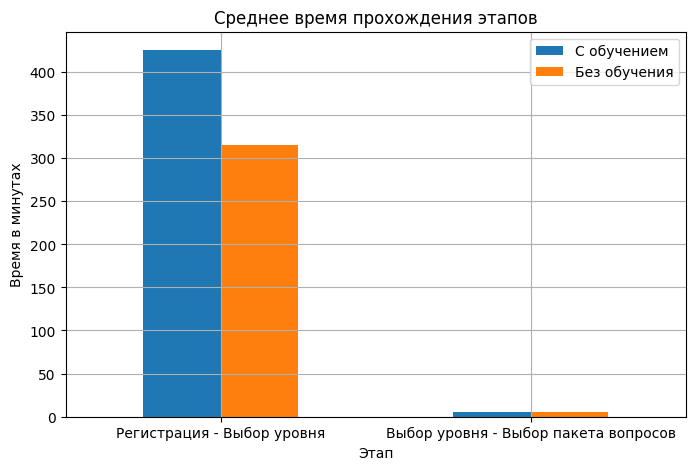

In [33]:
# Переведём время в минуты

reg_level_with = merged_with['timediff'].mean().total_seconds() / 60
level_pack_with = level_to_pack_with['timediff'].mean().total_seconds() / 60

reg_level_without = merged_without['timediff'].mean().total_seconds() / 60
level_pack_without = level_to_pack_without['timediff'].mean().total_seconds() / 60

plot_df = pd.DataFrame({'С обучением': [reg_level_with, level_pack_with],
    'Без обучения': [reg_level_without, level_pack_without]},
    index=['Регистрация - Выбор уровня', 'Выбор уровня - Выбор пакета вопросов']
    )

plot_df.plot(
    kind='bar',
    grid=True,
    figsize=(8, 5)
)
plt.title('Среднее время прохождения этапов')
plt.ylabel('Время в минутах')
plt.xlabel('Этап')
plt.xticks(rotation=0)

# Вывод:
Время прохождения этапов отличается у пользователей, которые прошли обучение, и пользователей, которые его не начинали. Из диаграммы следует, что время от регистрации до выбора уровня больше у людей с обучением, в среднем около 400 минут (7 часов 5 минут). Это и логично, так как после регистрации нужно пройти обучение. Другая категория пользователей этот этап пропускает, и их время в среднем около 300 минут (5 часов 15 минут). Время от выбора уровня до выбора пакета вопросов одинаково у двух категорий — 5 минут.

## Цель 2. Влияние обучения на оплату

* Считаем оплату в каждой группе

In [ ]:
# Завершили обучение

purchase_df_1 = purchase_df[purchase_df['user_id'].isin(users_with_tutorial)]
paying_finished = purchase_df_1['user_id'].nunique()
percent_finished = paying_finished / len(users_with_tutorial) * 100

# Начали, но не завершили

purchase_df_2 = purchase_df[purchase_df['user_id'].isin(set_users_not_finished_but_started_tutorial)]
paying_not_finished = purchase_df_2['user_id'].nunique()
percent_not_finished = paying_not_finished / len(set_users_not_finished_but_started_tutorial) * 100

# Не начинали

purchase_df_3 = purchase_df[purchase_df['user_id'].isin(users_without_tutorial)]
paying_not_started = purchase_df_3['user_id'].nunique()
percent_not_started = paying_not_started / len(users_without_tutorial) * 100

print("Процент оплативших")
print(f"Завершили обучение: {percent_finished:.2f}%")
print(f"Начали, но не завершили: {percent_not_finished:.2f}%")
print(f"Не начинали обучение: {percent_not_started:.2f}%")


Процент оплативших
Завершили обучение: 14.12%
Начали, но не завершили: 8.15%
Не начинали обучение: 0.27%


* Считаем количество обучений без удаления дубликатов

In [39]:
tutorial_counts = total_events_df[total_events_df['event_type'] == 'tutorial_finish'].groupby('user_id').size().reset_index(name='tutorials_finished')
paid_users = purchase_df['user_id'].unique()
tutorial_counts['is_paid'] = tutorial_counts['user_id'].isin(paid_users)

paid_by_tutorials = tutorial_counts.groupby('tutorials_finished')['is_paid'].mean().reset_index()
paid_by_tutorials['is_paid'] = paid_by_tutorials['is_paid'] * 100

print("Зависимость от количества обучений")
print(paid_by_tutorials.to_string(index=False))

Зависимость от количества обучений
 tutorials_finished   is_paid
                  1 14.260761
                  2 13.777441
                  3 12.753623
                  4 10.674157
                  5 16.239316
                  6 14.851485
                  7 15.463918
                  8 11.111111
                  9 18.181818


* Визуализация

Text(0.5, 1.0, 'Зависимость доли оплаты от числа пройденных обучений')

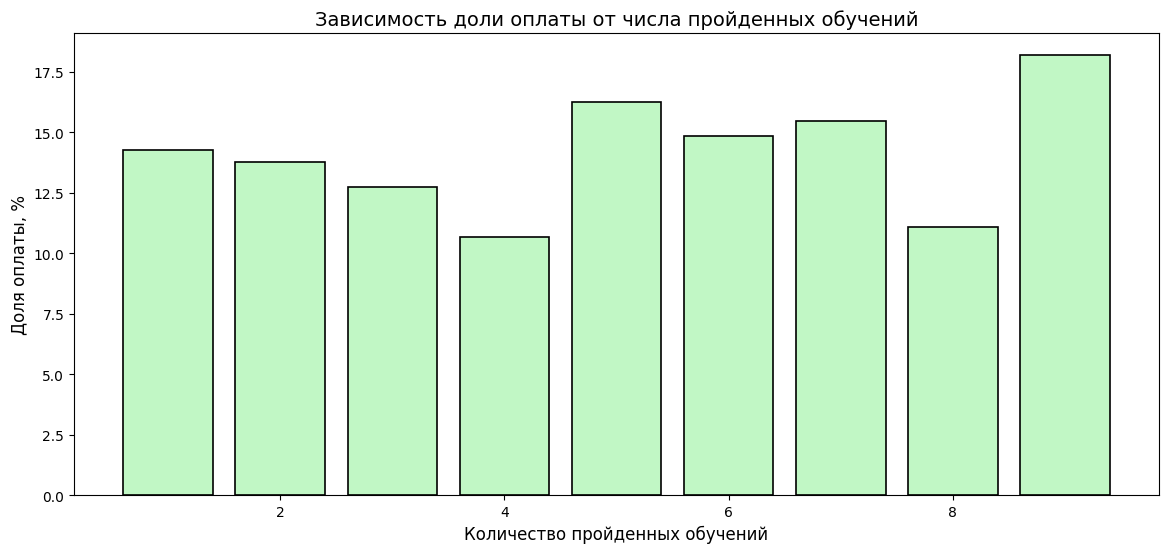

In [77]:
data = pd.DataFrame({'tutorials_finished': [1,2,3,4,5,6,7,8,9],
    'is_paid': [14.26, 13.78, 12.75, 10.67, 16.24, 14.85, 15.46, 11.11, 18.18]})

plt.figure(figsize=(14, 6))
plt.bar(
    paid_by_tutorials['tutorials_finished'],
    paid_by_tutorials['is_paid'],
    color='#C1F7C5',
    edgecolor='black',
    linewidth=1.2
)

plt.xlabel('Количество пройденных обучений', fontsize=12)
plt.ylabel('Доля оплаты, %', fontsize=12)
plt.title('Зависимость доли оплаты от числа пройденных обучений', fontsize=14)

([<matplotlib.patches.Wedge at 0x1cc37ad2580>,
 [Text(-1.1066122944300387, -0.4641219988497479, 'Завершили обучение'),
  Text(1.0298298480747108, 0.386588261609711, 'Начали, но не завершили'),
  Text(0.04180331468735527, 1.0992053870324463, 'Не начинали обучение')],
 [Text(-0.6455238384175226, -0.2707378326623529, '62.6%'),
  Text(0.5617253716771149, 0.21086632451438778, '36.1%'),
  Text(0.02280180801128469, 0.5995665747449707, '1.2%')])

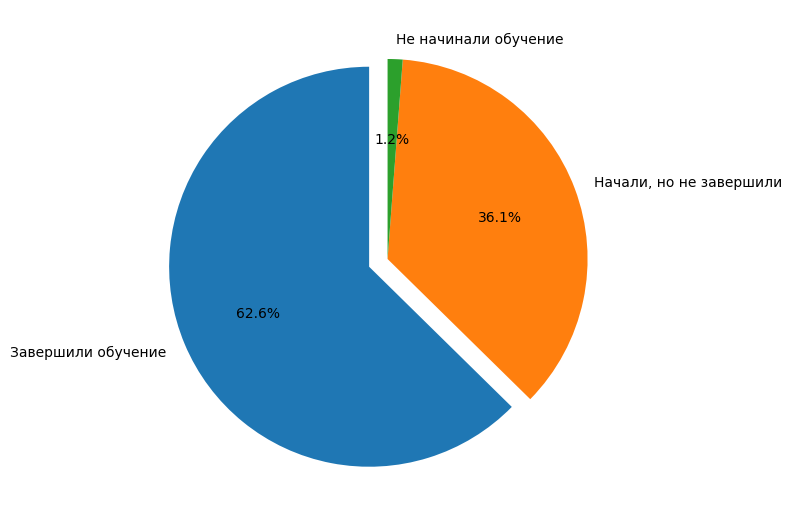

In [81]:
fig2 = plt.figure(figsize=(5, 5))
axes = fig2.add_axes([0,0,1,1])
sizes = [percent_finished, percent_not_finished, percent_not_started]
labels = ['Завершили обучение', 'Начали, но не завершили', 'Не начинали обучение']
axes.pie(sizes, labels=labels, autopct = '%.1f%%', explode = [0.1,0,0], startangle=90)

# Вывод:
Из данных следует, что зависимости между вероятностью оплаты и количеством обучений нет. Успешное обучение само по себе влияет на оплату, и не имеет значения, каким этапом оно шло. Больше половины (62,6%) оплативших завершили обучение. 36,1% пользователей оплатили платные игры из категории начавших обучение, но не закончивших его. Самую малую долю (1,2%) занимают игроки, которые не проходили обучение.

Нет зависимости оплаты от количества обучения. По диаграмме можем увидеть, что доля оплативших с первого прохождения обучения больше, чем в восьмой раз. И наоборот: в девятом значении обучения процент оплаты больше, чем в четвёртом.

Так как оплата зависит от обучения, рекомендуется обратить внимание: почему пользователи не проходят обучение, технические стороны приложения, всем ли доступно предложение об обучении, добавить бонус за обучение (если его нет).

## Цель 3. Прозрачность процесса взаимодействия с игрой

In [2]:
# Находим пользователей с обучением и выбором уровня

events_filtered = events_df[events_df['event_type'].isin(['tutorial_start', 'level_choice'])]

# Для каждого пользователя берем минимальное время каждого события

pivot_df = events_filtered.pivot_table(

    index='user_id', 

    columns='event_type', 

    values='start_time', 

    aggfunc='min'

).dropna()  

# Проверяем порядок

pivot_df['wrong_order'] = pivot_df['tutorial_start'] < pivot_df['level_choice']

# 5.3 Считаем результаты

wrong_order = pivot_df['wrong_order'].sum()

right_order = len(pivot_df) - wrong_order

total = len(pivot_df)

print(f"Всего пользователей с обоими событиями: {total}")

print(f"Начали обучение ДО выбора уровня: {wrong_order} ({wrong_order/total*100:.1f}%)")

print(f"Начали обучение ПОСЛЕ выбора уровня: {right_order} ({right_order/total*100:.1f}%)")

Всего пользователей с обоими событиями: 8244
Начали обучение ДО выбора уровня: 8244 (100.0%)
Начали обучение ПОСЛЕ выбора уровня: 0 (0.0%)


## Вывод:
Все пользователи из приведённых данных сначала проходят обучение, затем выбирают уровень сложности. Это логически правильно, так как сначала идёт регистрация, затем обучение и выбор уровня. Процесс прозрачен, аномалий нет.